

El presente proyecto se enfoca en la clasificación de expresiones faciales utilizando técnicas de visión por computadora y aprendizaje profundo. Para ello, se emplea el conjunto de datos **FER-2013** (Facial Expression Recognition), el cual contiene imágenes en escala de grises de rostros humanos con diferentes emociones etiquetadas. Este dataset es ampliamente utilizado para tareas de reconocimiento de emociones, ya que incluye siete clases: *Angry, Disgust, Fear, Happy, Sad, Surprise* y *Neutral*.

El objetivo es evaluar el impacto de aplicar filtros de preprocesamiento, como el filtro de Sobel, sobre la calidad del aprendizaje de un modelo de red neuronal convolucional (CNN), comparando el rendimiento con imágenes originales. Esta comparación permite analizar cómo la extracción de contornos influye en la detección automática de expresiones faciales.

**Dataset utilizado:**
[FER-2013 Facial Expression Dataset – Kaggle](https://www.kaggle.com/datasets/pankaj4321/fer-2013-facial-expression-dataset)



In [ ]:
import os
import numpy as np
import pandas as pd 
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix  
from tensorflow.keras.layers import BatchNormalization
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import  GlobalAveragePooling2D, Input



In [40]:
data = r"C:\Users\celso\Downloads\archive"  
img_size = (48, 48)

batch_size = 32
num_classes = 7

Aplicamos un filtro Sobel para resaltar bordes en imágenes antes de pasarlas al modelo de clasificación.

In [ ]:

def sobel_filter(img):
    img = img.astype(np.uint8)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = cv2.normalize(sobel, None, 0, 255, cv2.NORM_MINMAX)
    return sobel.astype(np.uint8)


basic_gen = ImageDataGenerator(rescale=1./255)


def sobel_preprocessing(img):
    img = sobel_filter(img)
    img = np.expand_dims(img, axis=-1)  
    return img / 255.0


sobel_gen = ImageDataGenerator(preprocessing_function=sobel_preprocessing)


Ahora  centralicemos y automaticemos la carga de datos para entrenar, validar y evaluar el modelo de clasificación de imágenes

In [42]:

def get_generators(base_path, use_sobel=False):
    gen = sobel_gen if use_sobel else basic_gen
    train = gen.flow_from_directory(os.path.join(base_path, 'train'),
                                    target_size=img_size,
                                    color_mode='grayscale',
                                    class_mode='categorical',
                                    batch_size=batch_size,
                                    shuffle=True)

    val = gen.flow_from_directory(os.path.join(base_path, 'val'),
                                  target_size=img_size,
                                  color_mode='grayscale',
                                  class_mode='categorical',
                                  batch_size=batch_size,
                                  shuffle=False)

    test = gen.flow_from_directory(os.path.join(base_path, 'test'),
                                   target_size=img_size,
                                   color_mode='grayscale',
                                   class_mode='categorical',
                                   batch_size=batch_size,
                                   shuffle=False)
    return train, val, test


En esta sección mostramos ejemplos de imágenes del generador de datos, comparando las imágenes originales con las procesadas por el filtro Sobel

Found 28709 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Found 28709 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.


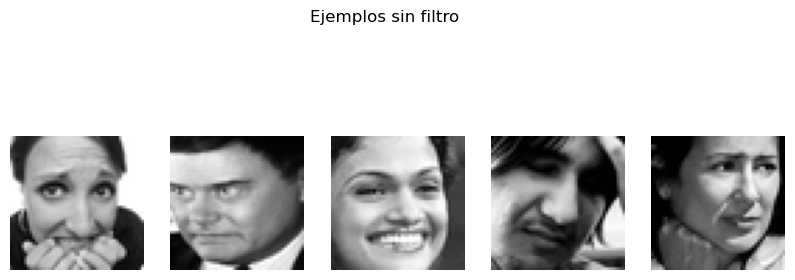

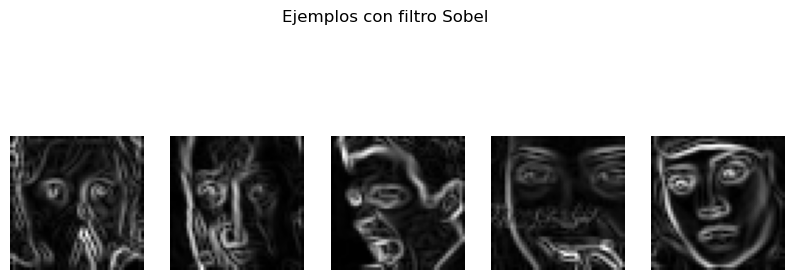

In [43]:

def show_example_images(generator, title):
    images, labels = next(generator)
    plt.figure(figsize=(10, 4))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

train_orig, val_orig, test_orig = get_generators(data, use_sobel=False)
train_sobel, val_sobel, test_sobel = get_generators(data, use_sobel=True)


show_example_images(train_orig, "Ejemplos sin filtro")
show_example_images(train_sobel, "Ejemplos con filtro Sobel")

Siguiendo con  el entrenamiento de la  red neuronal convolucional (CNN) para clasificar las emociones en imágenes de rostros, utilizando dos flujos de trabajo con imágenes originales y con elfiltro Sobel 

In [44]:

def build_model(input_shape=(48,48,1), num_classes=7, dropout_rate=0.5):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

model_orig = build_model()
print("\nEntrenando modelo con imágenes originales...\n")
history_orig = model_orig.fit(
    train_orig,
    validation_data=val_orig,
    epochs=265,
    callbacks=[early_stop, reduce_lr]
)











Entrenando modelo con imágenes originales...

Epoch 1/25


c:\Users\celso\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\celso\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.2391 - loss: 1.9580 - val_accuracy: 0.2892 - val_loss: 1.7615 - learning_rate: 0.0010
Epoch 2/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 65s 72ms/step - accuracy: 0.2930 - loss: 1.7002 - val_accuracy: 0.3026 - val_loss: 1.6978 - learning_rate: 0.0010
Epoch 3/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 67s 75ms/step - accuracy: 0.3156 - loss: 1.6537 - val_accuracy: 0.3199 - val_loss: 1.6187 - learning_rate: 0.0010
Epoch 4/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 68s 75ms/step - accuracy: 0.3211 - loss: 1.6304 - val_accuracy: 0.3146 - val_loss: 1.6326 - learning_rate: 0.0010
Epoch 5/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 68s 75ms/step - accuracy: 0.3381 - loss: 1.5848 - val_accuracy: 0.3413 - val_loss: 1.6077 - learning_rate: 0.0010
Epoch 6/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 67s 74ms/step - accuracy: 0.3398 - loss: 1.5660 - val_accuracy: 0.3176 - val_loss: 1.6439 - learning_rate: 0.0010
Epoch 7/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 66s 74ms/step - accuracy: 0.3533 - loss: 1.5509

In [45]:

model_sobel = build_model()
print("\nEntrenando modelo con imágenes filtradas (Sobel)...\n")
history_sobel = model_sobel.fit(
    train_sobel,
    validation_data=val_sobel,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)




Entrenando modelo con imágenes filtradas (Sobel)...

Epoch 1/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 70s 77ms/step - accuracy: 0.2594 - loss: 1.9922 - val_accuracy: 0.3263 - val_loss: 1.6918 - learning_rate: 0.0010
Epoch 2/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 68s 75ms/step - accuracy: 0.3299 - loss: 1.6357 - val_accuracy: 0.3920 - val_loss: 1.5392 - learning_rate: 0.0010
Epoch 3/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 68s 75ms/step - accuracy: 0.3719 - loss: 1.5600 - val_accuracy: 0.4260 - val_loss: 1.4886 - learning_rate: 0.0010
Epoch 4/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 68s 76ms/step - accuracy: 0.3862 - loss: 1.5267 - val_accuracy: 0.3614 - val_loss: 1.6004 - learning_rate: 0.0010
Epoch 5/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 69s 76ms/step - accuracy: 0.4147 - loss: 1.4757 - val_accuracy: 0.4505 - val_loss: 1.4270 - learning_rate: 0.0010
Epoch 6/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 71s 79ms/step - accuracy: 0.4280 - loss: 1.4351 - val_accuracy: 0.4037 - val_loss: 1.5586 - learning_rate: 0.0010
Epoch 7/25
898/898 ━━━

Por ultimo bloque compqaramos el  análisis  visual y numéricamente con el rendimiento de ambos modelos (original vs. Sobel).

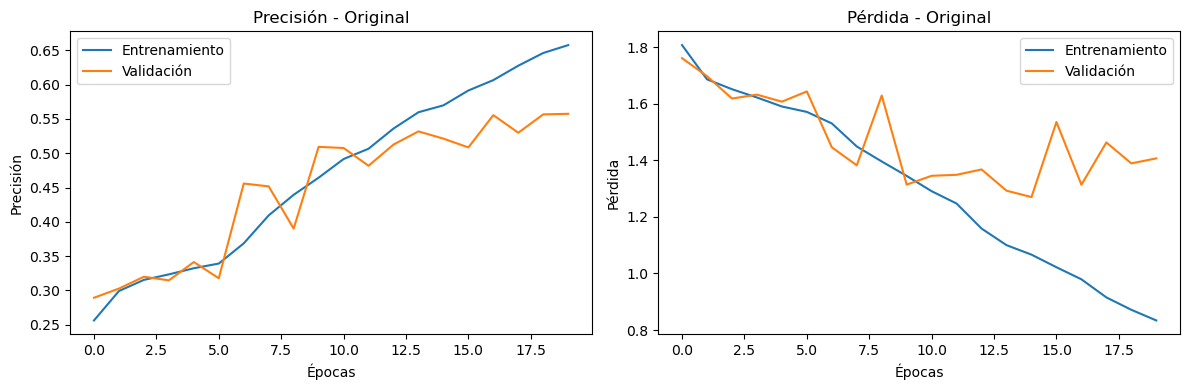

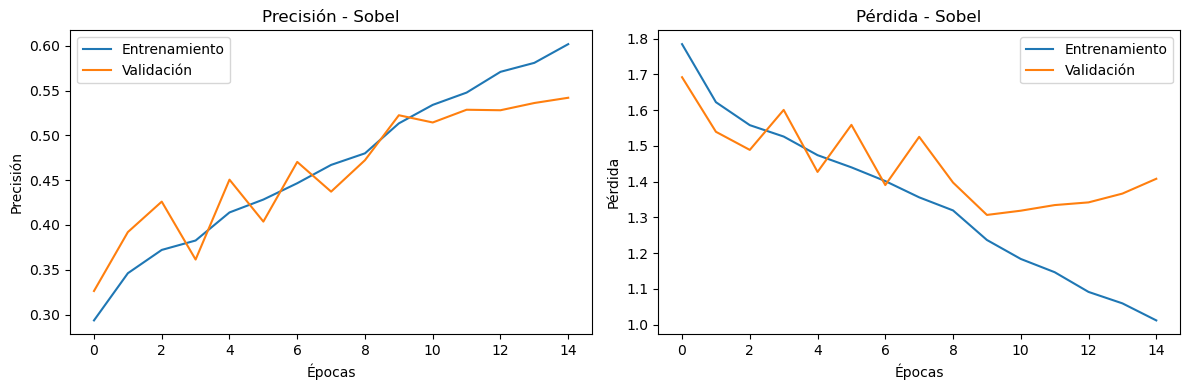

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step

Reporte de clasificación - Original
              precision    recall  f1-score   support

       Angry       0.44      0.34      0.38       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.35      0.24      0.28       528
       Happy       0.85      0.75      0.80       879
     Neutral       0.44      0.68      0.54       626
         Sad       0.35      0.46      0.40       594
    Surprise       0.79      0.61      0.69       416

    accuracy                           0.53      3589
   macro avg       0.46      0.44      0.44      3589
weighted avg       0.55      0.53      0.53      3589



c:\Users\celso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\celso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\celso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


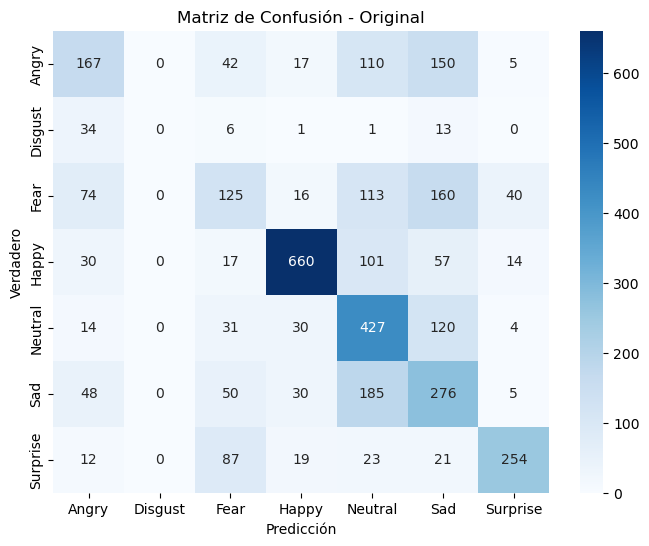

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step

Reporte de clasificación - Sobel
              precision    recall  f1-score   support

       Angry       0.38      0.24      0.30       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.32      0.15      0.21       528
       Happy       0.79      0.78      0.79       879
     Neutral       0.38      0.68      0.49       626
         Sad       0.37      0.46      0.41       594
    Surprise       0.77      0.58      0.66       416

    accuracy                           0.51      3589
   macro avg       0.43      0.41      0.41      3589
weighted avg       0.51      0.51      0.49      3589



c:\Users\celso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\celso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\celso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


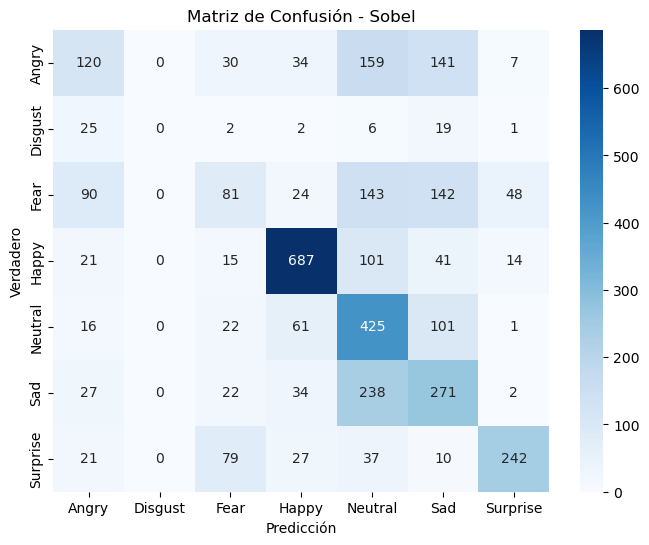

In [52]:

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'Precisión - {title}')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'Pérdida - {title}')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_orig, "Original")
plot_history(history_sobel, "Sobel")


class_names = list(test_orig.class_indices.keys())

def evaluate_model(model, test_gen, title):
    y_true = test_gen.classes
    y_pred_probs = model.predict(test_gen)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nReporte de clasificación - {title}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(f'Matriz de Confusión - {title}')
    plt.xlabel('Predicción')
    plt.ylabel('Verdadero')
    plt.show()




evaluate_model(model_orig, test_orig, "Original")
evaluate_model(model_sobel, test_sobel, "Sobel")


Al comparar los resultados del modelo original con el que utiliza el filtro Sobel, se observa que el rendimiento general es bastante similar, pero con algunas diferencias clave que vale la pena destacar.

El modelo original alcanza una precisión del 53%, mientras que la versión con filtro Sobel obtiene un 51%. Esta pequeña diferencia podría no parecer significativa, pero al analizar el comportamiento por clases se revelan patrones importantes.

Para las emociones positivas como "Happy" y "Surprise", ambos modelos muestran un buen desempeño, aunque con una ligera ventaja para el modelo original. Sin embargo, donde realmente se nota la diferencia es en la detección de emociones negativas. El filtro Sobel parece dificultar especialmente el reconocimiento de emociones como "Angry" y "Fear", donde los puntajes F1 son notablemente más bajos que en el modelo original.

Con respecto a las graficas , se comparó el desempeño utilizando imágenes originales y otras procesadas con el filtro de Sobel. Con las imágenes originales, el modelo alcanzó una precisión de hasta 65 % en entrenamiento y 55 % en validación, pero con fluctuaciones en la pérdida, lo que sugiere posible sobreajuste. En contraste, el modelo entrenado con imágenes filtradas tuvo un desempeño más estable, con una precisión final cercana al 60 % en entrenamiento y una validación similar, pero con menor variabilidad en la pérdida.

Esto indica que el filtro de Sobel no  ayudó al modelo a enfocarse en características clave como contornos y bordes. Aunque la diferencia no fue extrema, el filtro resultó inutil para estabilizar el aprendizaje y reducir el ruido visual.

